In [1]:
# Pretty inline figures
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

In [7]:
%autoreload 0


# Prepare to train

In [8]:
!pip install -q "diffusers==0.21.4" "huggingface_hub==0.19.4"


DEPRECATION: lightning-lite 1.8.0 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of lightning-lite or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: pytorch-lightning 1.8.0 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [9]:
!pip install -q rdkit-pypi


DEPRECATION: lightning-lite 1.8.0 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of lightning-lite or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
DEPRECATION: pytorch-lightning 1.8.0 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# --- paths & imports
import os, sys, json, pathlib, time, numpy as np, torch, matplotlib.pyplot as plt
REPO = pathlib.Path("/nfs/team361/mv11/GGSD")
sys.path.append(str(REPO))

from dataset.load_data_generated import LaplacianDatasetNX
from models.diffusion import SpectralDiffusion
from models.predictor import Predictor


In [4]:
%load_ext autoreload
%autoreload 1         
%aimport models, dataset, utils


In [7]:
# Pretty inline figures
%config InlineBackend.figure_format = 'retina'

import os, sys, json, pathlib, time, numpy as np, torch, matplotlib.pyplot as plt
from types import SimpleNamespace

# point to the GGSD repo on disk
REPO = pathlib.Path("/nfs/team361/mv11/GGSD")
sys.path.append(str(REPO))

# where to save this run’s artifacts
EXP = pathlib.Path("/nfs/team361/mv11/experiments/ggsd_proteins")
FIG = EXP / "figs"; FIG.mkdir(parents=True, exist_ok=True)
CKPT = EXP / "checkpoints"; CKPT.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# lightning / GGSD bits
from dataset.load_data_generated import LaplacianDatasetNX
from models.diffusion import SpectralDiffusion
from models.predictor import Predictor
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping


device: cuda


In [8]:
# If you didn't already in this kernel: load PROTEINS via PyG and convert to NetworkX

import os
os.environ["PYG_DATASET_ROOT"] = "/nfs/team361/mv11/DATASETS/pyg"

# allow PyG pickles under torch>=2.6
import torch.serialization as ts
from torch_geometric.data import Data, Batch
ts.add_safe_globals([Data, Batch])

import torch_geometric
from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx
import networkx as nx, pickle

# Load PROTEINS
ds = TUDataset(root=os.environ["PYG_DATASET_ROOT"], name="PROTEINS")

def pyg_to_nx(d):
    G = to_networkx(d, to_undirected=True)
    if d.x is not None:
        for i in range(d.num_nodes):
            G.nodes[i]["x"] = d.x[i].cpu().numpy()
    G.graph["y"] = int(d.y.item()) if d.y is not None else None
    return G

Gs = [pyg_to_nx(ds[i]) for i in range(len(ds))]

# Clean ids and drop isolated nodes; save to REPO/data/proteins.pkl
DATA_DIR = REPO / "data"; DATA_DIR.mkdir(exist_ok=True)
DATASET = "proteins"
PKL = DATA_DIR / f"{DATASET}.pkl"

Gs_clean = []
for G in Gs:
    H = nx.convert_node_labels_to_integers(G)
    iso = [u for u,deg in H.degree() if deg == 0]
    H.remove_nodes_from(iso)
    Gs_clean.append(H)

with open(PKL, "wb") as f:
    pickle.dump(Gs_clean, f)
print(f"Saved {len(Gs_clean)} graphs → {PKL}")


Saved 1113 graphs → /nfs/team361/mv11/GGSD/data/proteins.pkl


In [9]:
class History(pl.Callback):
    def __init__(self): self.log = []
    def on_train_epoch_end(self, trainer, pl_module):
        row = {"epoch": trainer.current_epoch}
        for k,v in trainer.callback_metrics.items():
            try: row[k] = float(v)
            except: pass
        self.log.append(row)

def plot_history(hist, keys, title):
    if not hist: return
    xs = [h["epoch"] for h in hist]
    plt.figure(figsize=(6,3))
    for k in keys:
        ys = [h.get(k, np.nan) for h in hist]
        plt.plot(xs, ys, marker="o", label=k)
    plt.xlabel("epoch"); plt.title(title); plt.legend(); plt.grid(alpha=.3); plt.show()


# Train

## Train the diffusion model (stage 1)

learning to denoise eigenpairs of the (normalized) Laplacian.

In [19]:
# 1) Reload the module and REBIND the class name in your notebook
from importlib import reload
import models.diffusion as md
reload(md)

# VERY IMPORTANT: rebind the notebook's SpectralDiffusion to the reloaded class
SpectralDiffusion = md.SpectralDiffusion

# 2) Hard override: no scheduler, and no scheduler access in training_step
def _cfg_opts(self):
    import torch
    return torch.optim.Adam(self.parameters(), lr=self.args.lr)

def _train_step_no_sched(self, batch, batch_idx):
    # manual optimization without any lr_schedulers() calls
    opt = self.optimizers()
    x = batch[0].float()
    y = batch[1].float()
    m = batch[2].float()
    em = batch[3].float()

    loss = self.get_loss(x, y, m=m, em=em)
    self.manual_backward(loss)
    opt.step()
    opt.zero_grad()

    # simple loss log; no lr logging (since no scheduler)
    self.log('loss', float(loss.detach().cpu()), on_step=False, on_epoch=True)

# Apply patches to the EXACT class you will instantiate
SpectralDiffusion.configure_optimizers = _cfg_opts
SpectralDiffusion.training_step = _train_step_no_sched
SpectralDiffusion.on_train_epoch_end = lambda self: None


In [21]:
# Replace the previous History helper with a safe version
import pytorch_lightning as pl

class History(pl.Callback):
    def __init__(self):
        self.records = []          # <- renamed from .log

    def on_train_epoch_end(self, trainer, pl_module):
        row = {"epoch": trainer.current_epoch}
        for k, v in trainer.callback_metrics.items():
            try:
                row[k] = float(v)
            except Exception:
                pass
        self.records.append(row)


In [22]:
import argparse 

def train_diffusion_notebook(
    dataset="proteins", k=16, smallest=False, scaler="standard",
    batch_size=128, lr=1e-4, num_steps=1000, layers=6, latent_dim=256,
    max_val_interval=2500, log_every=250, seed=2023, max_epochs_cap=20000
):
    pl.seed_everything(seed)

    # Build datasets; this also creates REPO/data/proteins_*cache*.torch on first run
    train_set = LaplacianDatasetNX(dataset, str((REPO/"data")/dataset), point_dim=k,
                                   smallest=smallest, split='train_train',
                                   scaler=scaler, nodefeatures=False, device="cpu")
    valid_set = LaplacianDatasetNX(dataset, str((REPO/"data")/dataset), point_dim=k,
                                   smallest=smallest, split='train_val',
                                   scaler=scaler, nodefeatures=False)

    train_set.get_extra_data(False)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
    valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=len(valid_set), shuffle=False, num_workers=0)

    args = argparse.Namespace(       
        num_steps=num_steps, residual=True,
        batch_size=batch_size, lr=lr, max_epochs=500_000,
        seed=seed, device=device, val_check_interval=max_val_interval, log_every_n_steps=log_every,
        wandb=False, model_tag="nb", dataset=dataset, k=k, smallest=smallest, scaler=scaler,
        latent_dim=latent_dim, layers=layers, use_mask=True
    )
    model = SpectralDiffusion(args)

    h = History()
    ckpt_cb = ModelCheckpoint(dirpath=CKPT, filename=f"diffusion_{dataset}_k{k}"+"-{epoch:04d}",
                              save_last=True, save_top_k=1, monitor="loss", mode="min")
    es = EarlyStopping(monitor="loss", min_delta=-1e-1, patience=10, mode="min")

    trainer = pl.Trainer(
        accelerator="auto",
        callbacks=[h, ckpt_cb, es],
        logger=False, log_every_n_steps=log_every,
        check_val_every_n_epoch=None, val_check_interval=max_val_interval,
        max_epochs=max_epochs_cap
    )
    trainer.fit(model, train_loader, valid_loader)
    best = ckpt_cb.best_model_path or ckpt_cb.last_model_path
    print("Diffusion checkpoint:", best)
    # diff_hist = h.records   # <- was h.log
    return best, h.records # h.log 

diff_ckpt, diff_hist = train_diffusion_notebook(k=16)
plot_history(diff_hist, ["loss"], "Diffusion training loss (↓ better)")


Global seed set to 2023
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type        | Params
------------------------------------------
0 | diffusion | Transformer | 20.1 M
------------------------------------------
20.1 M    Trainable params
0         Non-trainable params
20.1 M    Total params
80.464    Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 192 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 192 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

AttributeError: 'list' object has no attribute 'dataset'

 fast run

Global seed set to 2023
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type        | Params
------------------------------------------
0 | diffusion | Transformer | 20.1 M
------------------------------------------
20.1 M    Trainable params
0         Non-trainable params
20.1 M    Total params
80.464    Total estimated model params size (MB)
/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 192 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


Diffusion checkpoint: 
Time elapsed (train): 377.58059034403414


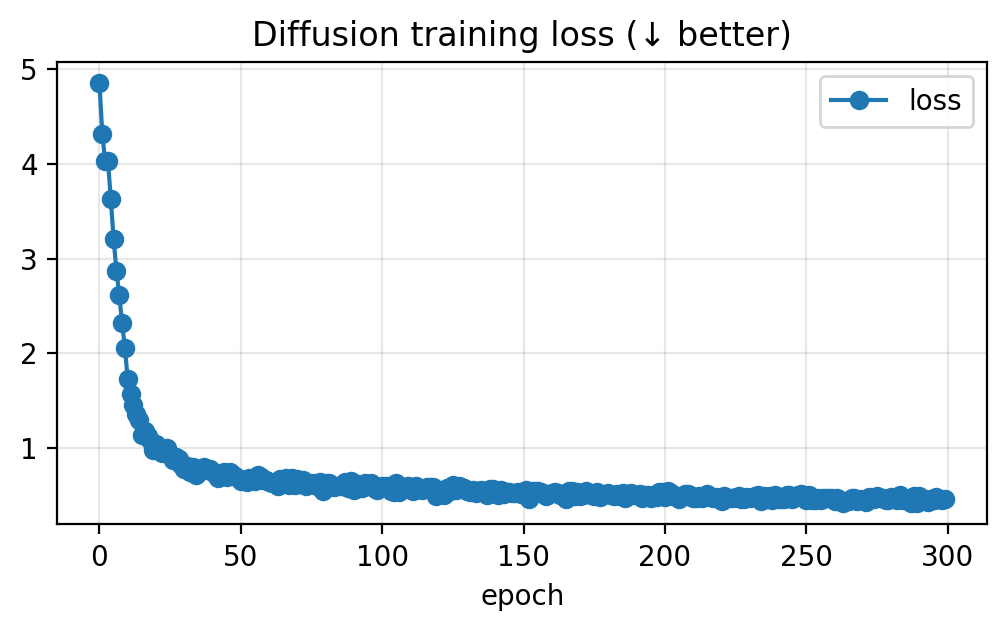

Global seed set to 2023


IsADirectoryError: [Errno 21] Is a directory: '/nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/notebooks'

In [25]:
# --- 0) Reload + rebind ------------------------------------------------------
from importlib import reload
import models.diffusion as md
reload(md)
SpectralDiffusion = md.SpectralDiffusion  # IMPORTANT

# --- 1) Patch SpectralDiffusion for a quick run (no sched, no validation) ---
def _cfg_opts(self):
    import torch
    return torch.optim.Adam(self.parameters(), lr=self.args.lr)

def _train_step_no_sched(self, batch, batch_idx):
    opt = self.optimizers()
    x = batch[0].float()
    y = batch[1].float()
    m = batch[2].float()
    em = batch[3].float()
    loss = self.get_loss(x, y, m=m, em=em)
    self.manual_backward(loss)
    opt.step()
    opt.zero_grad()
    self.log('loss', float(loss.detach().cpu()), on_step=False, on_epoch=True)

SpectralDiffusion.configure_optimizers      = _cfg_opts
SpectralDiffusion.training_step             = _train_step_no_sched
SpectralDiffusion.on_train_epoch_end        = lambda self: None
SpectralDiffusion.on_validation_epoch_end   = lambda self: None  # skip heavy eval

# --- 2) Lightweight History --------------------------------------------------
import pytorch_lightning as pl
class History(pl.Callback):
    def __init__(self): self.records = []
    def on_train_epoch_end(self, trainer, pl_module):
        row = {"epoch": trainer.current_epoch}
        for k, v in trainer.callback_metrics.items():
            try: row[k] = float(v)
            except: pass
        self.records.append(row)

# --- 3) Quick diffusion training --------------------------------------------
import argparse, os, torch
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Timer

def train_diffusion_quick(
    dataset="proteins", k=16, smallest=False, scaler="standard",
    batch_size=128, lr=1e-4, num_steps=1000, layers=6, latent_dim=256,
    seed=2023, MAX_EPOCHS_QUICK=300
):
    pl.seed_everything(seed)

    # robust root
    from pathlib import Path
    root = (REPO if 'REPO' in globals() else Path('.'))
    data_dir = str((root/"data")/dataset)

    # datasets/loaders
    from dataset.load_data_generated import LaplacianDatasetNX
    train_set = LaplacianDatasetNX(dataset, data_dir, point_dim=k,
                                   smallest=smallest, split='train_train',
                                   scaler=scaler, nodefeatures=False, device="cpu")
    valid_set = LaplacianDatasetNX(dataset, data_dir, point_dim=k,
                                   smallest=smallest, split='train_val',
                                   scaler=scaler, nodefeatures=False)
    train_set.get_extra_data(False)

    num_workers = min(6, os.cpu_count() or 1)
    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True,
        persistent_workers=(num_workers > 0),
        prefetch_factor=4 if num_workers>0 else 2
    )
    valid_loader = torch.utils.data.DataLoader(
        valid_set, batch_size=len(valid_set), shuffle=False, num_workers=0
    )

    args = argparse.Namespace(
        num_steps=num_steps, residual=True, batch_size=batch_size, lr=lr,
        max_epochs=500_000, seed=seed,
        device=('cuda' if torch.cuda.is_available() else 'cpu'),
        val_check_interval=10_000_000,  # effectively disable val
        log_every_n_steps=50, wandb=False, model_tag="nb",
        dataset=dataset, k=k, smallest=smallest, scaler=scaler,
        latent_dim=latent_dim, layers=layers, use_mask=True
    )
    model = SpectralDiffusion(args)

    h = History()
    ckpt_dir = str((CKPT if 'CKPT' in globals() else root/"ckpts"))
    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt_cb = ModelCheckpoint(dirpath=ckpt_dir, filename=f"diffusion_{dataset}_k{k}"+"-{epoch:04d}",
                              save_last=True, save_top_k=1, monitor="loss", mode="min")
    es = EarlyStopping(monitor="loss", min_delta=1e-4, patience=30, mode="min")
    timer = Timer()

    trainer = pl.Trainer(
        accelerator="auto",
        callbacks=[h, ckpt_cb, es, timer],
        logger=False, log_every_n_steps=50,
        check_val_every_n_epoch=None, val_check_interval=args.val_check_interval,
        max_epochs=MAX_EPOCHS_QUICK,
        num_sanity_val_steps=0       # <-- no sanity val; avoids hitting eval hooks
        # precision omitted => fp32 (robust across PL versions)
    )
    trainer.fit(model, train_loader, valid_loader)
    best = ckpt_cb.best_model_path or ckpt_cb.last_model_path
    print("Diffusion checkpoint:", best)
    print("Time elapsed (train):", timer.time_elapsed("train"))
    return best, h.records

# --- 4) Train quick diffusion ------------------------------------------------
diff_ckpt, diff_hist = train_diffusion_quick(k=16)
plot_history(diff_hist, ["loss"], "Diffusion training loss (↓ better)")

# --- 5) QUICK GAN training ---------------------------------------------------
def train_gan_quick(
    diffusion_ckpt, dataset="proteins", k=16, smallest=False, scaler="standard",
    n_graphs_train=128, n_graphs_test=64, sampling_steps=50,
    gen_layers=4, gen_channels=32, disc_layers=2, disc_channels=32,
    batch_size=8, lr=1e-4, rec_weight=1e-1, seed=2023,
    max_epochs=150, val_check_interval=200
):
    import torch, numpy as np
    from pathlib import Path
    from torch.utils.data import DataLoader, TensorDataset
    from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
    from models.predictor import Predictor
    from models.diffusion import SpectralDiffusion
    from dataset.load_data_generated import LaplacianDatasetNX

    pl.seed_everything(seed)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # load diffusion
    model = SpectralDiffusion.load_from_checkpoint(diffusion_ckpt, strict=False)
    args = model.hparams
    args.qm9 = args.dataset[:3] in ["qm9"]

    # real sets
    root = (REPO if 'REPO' in globals() else Path('.'))
    data_dir = str((root/"data")/dataset)
    graphs_train_set = LaplacianDatasetNX(dataset, data_dir, point_dim=k, smallest=smallest,
                                          split='train_train', nodefeatures=args.qm9)
    graphs_val_set   = LaplacianDatasetNX(dataset, data_dir, point_dim=k, smallest=smallest,
                                          split='train_val', nodefeatures=args.qm9)
    graphs_test_set  = LaplacianDatasetNX(dataset, data_dir, point_dim=k, smallest=smallest,
                                          split='test', nodefeatures=args.qm9)

    # pack some real data
    graphs_train_set.get_extra_data(False)
    real_eval = torch.stack([t[1] for t in graphs_train_set],0)
    real_evec = torch.stack([t[0] for t in graphs_train_set],0)
    real_adj  = torch.stack([t[-1][0] for t in graphs_train_set],0)
    real_emask = torch.stack([t[3] for t in graphs_train_set],0)
    real_edge_features = torch.stack([t[4] for t in graphs_train_set],0)

    real_evec, real_eval = graphs_train_set.unscale_xy(real_evec, real_eval)
    real_evec *= real_emask[:,None,:]; real_eval *= real_emask
    real_evec[:,:,k:] = torch.clamp(real_evec[:,:,k:], 0, 1)

    train_set = TensorDataset(real_evec, real_eval, real_adj, real_edge_features)

    # generate a small synthetic pool with the quick diffusion
    model.to(device)
    with torch.no_grad():
        n_nodes = list(graphs_train_set.sample_n_nodes(max(1, n_graphs_train-1))) + [graphs_train_set.n_max]
        gx, gy = model.sample_eigs(n_nodes, k+getattr(args,"feature_size",0),
                                   scale_xy=graphs_train_set.scale_xy,
                                   unscale_xy=graphs_train_set.unscale_xy,
                                   device=device, num_graphs=len(n_nodes),
                                   reproject=False, sampling_steps=sampling_steps)
    gens_train = TensorDataset(gx[:n_graphs_train].cpu(), gy[:n_graphs_train].cpu())
    gens_val   = TensorDataset(gx[n_graphs_train:n_graphs_train+n_graphs_test].cpu(),
                               gy[n_graphs_train:n_graphs_train+n_graphs_test].cpu())

    # concat loader (train gets (real_batch, gen_batch); val only read by callback)
    class ConcatDataset(torch.utils.data.Dataset):
        def __init__(self, *datasets, shuffle=-1):
            self.datasets = datasets; self.shuffle=[False]*len(datasets)
            if shuffle is not None: self.shuffle[shuffle]=True
        def __getitem__(self, i):
            import random
            return tuple(d[random.randint(1,len(d))-1] if s else d[i] for d,s in zip(self.datasets,self.shuffle))
        def __len__(self): return min(len(d) for d in self.datasets)

    loader = DataLoader(ConcatDataset(train_set, gens_train),
                        batch_size=batch_size, shuffle=True, num_workers=0)
    vloader = DataLoader(ConcatDataset(graphs_train_set, graphs_val_set, gens_val, shuffle=None),
                         batch_size=batch_size, shuffle=False, num_workers=0)

    # predictor args (shrunk for speed)
    args.n_max = graphs_train_set.n_max
    args.generator_layers = gen_layers
    args.generator_data_channels = gen_channels
    args.generator_init_emb_channels = 64
    args.generator_noise_latent_dim = 2
    args.discriminator_layers = disc_layers
    args.discriminator_data_channels = disc_channels
    args.rec_weight = rec_weight
    args.batch_size = batch_size
    args.max_epochs = max_epochs
    args.lr = lr
    args.val_check_interval = val_check_interval
    args.wandb = False

    ref = Predictor(args)
    ckpt = ModelCheckpoint(save_last=True, save_top_k=1, monitor='avg_degrad', mode='min')
    es   = EarlyStopping(monitor='avg_degrad', patience=50, mode='min')

    trainer = pl.Trainer(
        accelerator="auto",
        callbacks=[ckpt, es],
        logger=False,
        log_every_n_steps=len(loader),
        check_val_every_n_epoch=None,
        val_check_interval=val_check_interval,
        max_epochs=max_epochs,
        num_sanity_val_steps=0
        # precision omitted => fp32 (robust across PL versions)
    )
    trainer.fit(ref, loader, vloader)
    print("Predictor checkpoint:", ckpt.best_model_path or ckpt.last_model_path)

# --- 6) Kick off the tiny GAN training --------------------------------------
train_gan_quick(diff_ckpt, dataset="proteins", k=16)


In [ ]:
diff_ckpt, diff_hist = train_diffusion_quick(k=16)
plot_history(diff_hist, ["loss"], "Diffusion training loss (↓ better)")

In [35]:
print(f"diff_ckpt: {diff_ckpt}")
# print(f"diff_hist: {diff_hist}")
      

diff_ckpt: 


In [28]:
ls /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/

checkpoints/  figs/  logs/  notebooks/  samples/


In [29]:
ls /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/notebooks

ggsd.ipynb  ggsd_training.ipynb  prompt/


In [30]:
ls

ggsd.ipynb  ggsd_training.ipynb  prompt/


In [31]:
# --- Resolve a real checkpoint path ------------------------------------------
import os, glob

def resolve_diffusion_ckpt(diff_ckpt, dataset="proteins", k=16):
    """Return a valid .ckpt path. If given a dir/empty/None, search common folders."""
    # usable file
    if isinstance(diff_ckpt, str) and diff_ckpt and os.path.isfile(diff_ckpt):
        return diff_ckpt

    # candidate roots to search (most recent first)
    roots = []
    if isinstance(diff_ckpt, str) and os.path.isdir(diff_ckpt):
        roots.append(diff_ckpt)
    for cand in ("ckpts", "checkpoints", os.path.join("..", "checkpoints"), "."):
        if os.path.isdir(cand) and cand not in roots:
            roots.append(cand)

    patterns = [f"diffusion_{dataset}_k{k}-*.ckpt", "*.ckpt"]
    for root in roots:
        for pat in patterns:
            hits = sorted(
                glob.glob(os.path.join(root, pat)),
                key=lambda p: os.path.getmtime(p),
                reverse=True,
            )
            if hits:
                return hits[0]

    raise FileNotFoundError(
        "Couldn't find a diffusion checkpoint. If training printed an empty path, "
        "either rerun training with the fallback save below or pass an explicit ckpt path."
    )

# if diff_ckpt was empty/dir, this will fix it:
diff_ckpt = resolve_diffusion_ckpt(diff_ckpt, dataset="proteins", k=16)
print("Using diffusion checkpoint:", diff_ckpt)

# --- Reuse the existing train_gan_quick but make two tiny safety fixes -------
from importlib import reload
import models.diffusion as md
reload(md)
from models.diffusion import SpectralDiffusion
import pytorch_lightning as pl
import torch

def train_gan_quick(
    diffusion_ckpt, dataset="proteins", k=16, smallest=False, scaler="standard",
    n_graphs_train=128, n_graphs_test=64, sampling_steps=50,
    gen_layers=4, gen_channels=32, disc_layers=2, disc_channels=32,
    batch_size=8, lr=1e-4, rec_weight=1e-1, seed=2023,
    max_epochs=150, val_check_interval=200
):
    import numpy as np
    from pathlib import Path
    from torch.utils.data import DataLoader, TensorDataset
    from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
    from models.predictor import Predictor
    from dataset.load_data_generated import LaplacianDatasetNX

    pl.seed_everything(seed)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # 1) load diffusion (map_location guards multi-GPU/CPU)
    model = SpectralDiffusion.load_from_checkpoint(diffusion_ckpt, strict=False, map_location=device)
    args = model.hparams
    args.qm9 = args.dataset[:3] in ["qm9"]

    # 2) datasets
    root = (REPO if 'REPO' in globals() else Path('.'))
    data_dir = str((root/"data")/dataset)
    graphs_train_set = LaplacianDatasetNX(dataset, data_dir, point_dim=k, smallest=smallest,
                                          split='train_train', nodefeatures=args.qm9)
    graphs_val_set   = LaplacianDatasetNX(dataset, data_dir, point_dim=k, smallest=smallest,
                                          split='train_val', nodefeatures=args.qm9)
    graphs_test_set  = LaplacianDatasetNX(dataset, data_dir, point_dim=k, smallest=smallest,
                                          split='test', nodefeatures=args.qm9)

    graphs_train_set.get_extra_data(False)
    real_eval = torch.stack([t[1] for t in graphs_train_set],0)
    real_evec = torch.stack([t[0] for t in graphs_train_set],0)
    real_adj  = torch.stack([t[-1][0] for t in graphs_train_set],0)
    real_emask = torch.stack([t[3] for t in graphs_train_set],0)
    real_edge_features = torch.stack([t[4] for t in graphs_train_set],0)

    real_evec, real_eval = graphs_train_set.unscale_xy(real_evec, real_eval)
    real_evec *= real_emask[:,None,:]; real_eval *= real_emask
    real_evec[:,:,k:] = torch.clamp(real_evec[:,:,k:], 0, 1)
    train_set = TensorDataset(real_evec, real_eval, real_adj, real_edge_features)

    # 3) small synthetic pool from diffusion
    model.to(device)
    with torch.no_grad():
        n_nodes = list(graphs_train_set.sample_n_nodes(max(1, n_graphs_train-1))) + [graphs_train_set.n_max]
        gx, gy = model.sample_eigs(n_nodes, k+getattr(args,"feature_size",0),
                                   scale_xy=graphs_train_set.scale_xy,
                                   unscale_xy=graphs_train_set.unscale_xy,
                                   device=device, num_graphs=len(n_nodes),
                                   reproject=False, sampling_steps=sampling_steps)
    gens_train = TensorDataset(gx[:n_graphs_train].cpu(), gy[:n_graphs_train].cpu())
    gens_val   = TensorDataset(gx[n_graphs_train:n_graphs_train+n_graphs_test].cpu(),
                               gy[n_graphs_train:n_graphs_train+n_graphs_test].cpu())

    class ConcatDataset(torch.utils.data.Dataset):
        def __init__(self, *datasets, shuffle=-1):
            self.datasets = datasets; self.shuffle=[False]*len(datasets)
            if shuffle is not None: self.shuffle[shuffle]=True
        def __getitem__(self, i):
            import random
            return tuple(d[random.randint(1,len(d))-1] if s else d[i] for d,s in zip(self.datasets,self.shuffle))
        def __len__(self): return min(len(d) for d in self.datasets)

    loader = DataLoader(ConcatDataset(train_set, gens_train),
                        batch_size=batch_size, shuffle=True, num_workers=0)
    vloader = DataLoader(ConcatDataset(graphs_train_set, graphs_val_set, gens_val, shuffle=None),
                         batch_size=batch_size, shuffle=False, num_workers=0)

    # predictor args (quick)
    args.n_max = graphs_train_set.n_max
    args.generator_layers = gen_layers
    args.generator_data_channels = gen_channels
    args.generator_init_emb_channels = 64
    args.generator_noise_latent_dim = 2
    args.discriminator_layers = disc_layers
    args.discriminator_data_channels = disc_channels
    args.rec_weight = rec_weight
    args.batch_size = batch_size
    args.max_epochs = max_epochs
    args.lr = lr
    args.val_check_interval = val_check_interval
    args.wandb = False
    args.disc_ori = False  # <-- avoid AttributeError in predictor

    from models.predictor import Predictor
    ref = Predictor(args)
    ckpt = ModelCheckpoint(save_last=True, save_top_k=1, monitor='avg_degrad', mode='min')
    es   = EarlyStopping(monitor='avg_degrad', patience=50, mode='min')

    trainer = pl.Trainer(
        accelerator="auto",
        callbacks=[ckpt, es],
        logger=False,
        log_every_n_steps=len(loader),
        check_val_every_n_epoch=None,
        val_check_interval=val_check_interval,
        max_epochs=max_epochs,
        num_sanity_val_steps=0
    )
    trainer.fit(ref, loader, vloader)
    print("Predictor checkpoint:", ckpt.best_model_path or ckpt.last_model_path)

# --- Run the GAN -------------------------------------------------------------
train_gan_quick(diff_ckpt, dataset="proteins", k=16)


FileNotFoundError: Couldn't find a diffusion checkpoint. If training printed an empty path, either rerun training with the fallback save below or pass an explicit ckpt path.

In [37]:
#todo: clean all those shits up!

train diff again with path set

In [ ]:
cp /nfs/team361/mv11/GGSD/data/proteins.pkl /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/data

In [41]:
# --- 0) Reload + rebind (same as before) ------------------------------------
from importlib import reload
import pytorch_lightning as pl
import torch, os, glob
from pathlib import Path
import models.diffusion as md
reload(md)
SpectralDiffusion = md.SpectralDiffusion  # IMPORTANT

# --- 1) Patch for the quick run (same as before) ----------------------------
def _cfg_opts(self):
    import torch
    return torch.optim.Adam(self.parameters(), lr=self.args.lr)

def _train_step_no_sched(self, batch, batch_idx):
    opt = self.optimizers()
    x = batch[0].float(); y = batch[1].float(); m = batch[2].float(); em = batch[3].float()
    loss = self.get_loss(x, y, m=m, em=em)
    self.manual_backward(loss)
    opt.step(); opt.zero_grad()
    self.log('loss', float(loss.detach().cpu()), on_step=False, on_epoch=True)

SpectralDiffusion.configure_optimizers      = _cfg_opts
SpectralDiffusion.training_step             = _train_step_no_sched
SpectralDiffusion.on_train_epoch_end        = lambda self: None
SpectralDiffusion.on_validation_epoch_end   = lambda self: None

# --- 2) Utilities ------------------------------------------------------------
class History(pl.Callback):
    def __init__(self): self.records = []
    def on_train_epoch_end(self, trainer, pl_module):
        row = {"epoch": trainer.current_epoch}
        for k, v in trainer.callback_metrics.items():
            try: row[k] = float(v)
            except: pass
        self.records.append(row)

def project_root():
    """Find a parent that already has 'checkpoints' folder; otherwise use CWD."""
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p/"checkpoints").exists():
            return p
    return cwd

def resolve_diffusion_ckpt(diff_ckpt, dataset="proteins", k=16):
    """Return a valid .ckpt path or raise."""
    if isinstance(diff_ckpt, str) and diff_ckpt and os.path.isfile(diff_ckpt):
        return diff_ckpt
    roots = []
    if isinstance(diff_ckpt, str) and diff_ckpt and os.path.isdir(diff_ckpt):
        roots.append(diff_ckpt)
    root = project_root()
    for r in [root/"checkpoints", root/"ckpts", root, Path(".")]:
        if r.exists(): roots.append(str(r))
    patterns = [f"diffusion_{dataset}_k{k}-*.ckpt", f"diffusion_{dataset}_k{k}-final.ckpt", "*.ckpt"]
    for r in dict.fromkeys(roots):
        for pat in patterns:
            hits = sorted(glob.glob(os.path.join(r, pat)), key=os.path.getmtime, reverse=True)
            if hits: return hits[0]
    raise FileNotFoundError("No diffusion .ckpt found in checkpoints/ckpts/.  Re-train with forced save below.")

# --- 3) Train diffusion WITH a guaranteed save ------------------------------
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Timer
import argparse

def train_diffusion_quick_and_save(
    dataset="proteins", k=16, smallest=False, scaler="standard",
    batch_size=128, lr=1e-4, num_steps=1000, layers=6, latent_dim=256,
    seed=2023, MAX_EPOCHS_QUICK=300
):
    pl.seed_everything(seed)

    from dataset.load_data_generated import LaplacianDatasetNX
    root = project_root()
    data_dir = str((root/"data")/dataset)

    train_set = LaplacianDatasetNX(dataset, data_dir, point_dim=k,
                                   smallest=smallest, split='train_train',
                                   scaler=scaler, nodefeatures=False, device="cpu")
    valid_set = LaplacianDatasetNX(dataset, data_dir, point_dim=k,
                                   smallest=smallest, split='train_val',
                                   scaler=scaler, nodefeatures=False)
    train_set.get_extra_data(False)

    num_workers = min(6, os.cpu_count() or 1)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True,
                                               num_workers=num_workers, pin_memory=True,
                                               persistent_workers=(num_workers>0),
                                               prefetch_factor=4 if num_workers>0 else 2)
    valid_loader = torch.utils.data.DataLoader(valid_set, batch_size=len(valid_set), shuffle=False, num_workers=0)

    args = argparse.Namespace(
        num_steps=num_steps, residual=True, batch_size=batch_size, lr=lr,
        max_epochs=500_000, seed=seed, device=('cuda' if torch.cuda.is_available() else 'cpu'),
        val_check_interval=10_000_000, log_every_n_steps=50, wandb=False, model_tag="nb",
        dataset=dataset, k=k, smallest=smallest, scaler=scaler, latent_dim=latent_dim, layers=layers, use_mask=True
    )
    model = SpectralDiffusion(args)

    h = History()
    ckpt_dir = root/"checkpoints"     # <-- save where your tree already has this folder
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    ckpt_cb = ModelCheckpoint(dirpath=str(ckpt_dir),
                              filename=f"diffusion_{dataset}_k{k}"+"-{epoch:04d}",
                              save_last=True, save_top_k=1, monitor="loss", mode="min")
    es = EarlyStopping(monitor="loss", min_delta=1e-4, patience=30, mode="min")
    timer = Timer()

    trainer = pl.Trainer(
        accelerator="auto",
        callbacks=[h, ckpt_cb, es, timer],
        logger=False, log_every_n_steps=50,
        check_val_every_n_epoch=None, val_check_interval=args.val_check_interval,
        max_epochs=MAX_EPOCHS_QUICK, num_sanity_val_steps=0
    )
    trainer.fit(model, train_loader, valid_loader)

    # --- FORCE A CHECKPOINT even if callback didn’t fire ---
    final_path = ckpt_dir/f"diffusion_{dataset}_k{k}-final.ckpt"
    trainer.save_checkpoint(str(final_path))

    # prefer the real “best” if it exists, else use our forced final
    best = ckpt_cb.best_model_path or ckpt_cb.last_model_path or str(final_path)
    print("Diffusion checkpoint:", best)
    print("Time elapsed (train):", timer.time_elapsed("train"))
    return best, h.records

# Train & save
diff_ckpt, diff_hist = train_diffusion_quick_and_save(k=16)
print("Saved at:", diff_ckpt)


Global seed set to 2023


/nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/data/proteins
Comp dimensions...
Max # nodes: 620
Comp stats...
Comp Samples...
SAVING Tot #1113


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type        | Params
------------------------------------------
0 | diffusion | Transformer | 20.1 M
------------------------------------------
20.1 M    Trainable params
0         Non-trainable params
20.1 M    Total params
80.464    Total estimated model params size (MB)
/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 192 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


Diffusion checkpoint: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints/diffusion_proteins_k16-final.ckpt
Time elapsed (train): 377.95809617079794
Saved at: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints/diffusion_proteins_k16-final.ckpt


In [46]:
# === Stage-2 (Predictor/GAN) training — robust, with hotfixes ===
from importlib import reload
from pathlib import Path
import os, glob, torch
import pytorch_lightning as pl

# ——— Utilities ———
def project_root():
    """Prefer a parent that already has 'checkpoints'; else CWD."""
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        if (p / "checkpoints").exists():
            return p
    return cwd

def resolve_diffusion_ckpt(diff_ckpt="", dataset="proteins", k=16):
    """Return a valid diffusion .ckpt path or raise a helpful error."""
    if isinstance(diff_ckpt, str) and diff_ckpt and os.path.isfile(diff_ckpt):
        return diff_ckpt
    roots = []
    if isinstance(diff_ckpt, str) and diff_ckpt and os.path.isdir(diff_ckpt):
        roots.append(diff_ckpt)
    root = project_root()
    roots += [str(root/"checkpoints"), str(root/"ckpts"), str(root), "."]
    patterns = [f"diffusion_{dataset}_k{k}-*.ckpt", f"diffusion_{dataset}_k{k}-final.ckpt", "*.ckpt"]
    seen = set()
    for r in roots:
        if not os.path.isdir(r): 
            continue
        if r in seen:
            continue
        seen.add(r)
        for pat in patterns:
            hits = sorted(glob.glob(os.path.join(r, pat)), key=os.path.getmtime, reverse=True)
            if hits:
                return hits[0]
    raise FileNotFoundError(
        "No diffusion .ckpt found in checkpoints/ckpts/. "
        "Pass an explicit path or re-run diffusion training with a forced save."
    )

# ——— Imports (reload to pick up any edits) ———
import models.diffusion as md
reload(md)
from models.diffusion import SpectralDiffusion

# We'll import Predictor through its module so we can hot-patch safely if needed.
from models import predictor as predictor_mod
reload(predictor_mod)
Predictor = predictor_mod.Predictor

from dataset.load_data_generated import LaplacianDatasetNX
from torch.utils.data import DataLoader, TensorDataset

# ——— Hotfix: patch Predictor.training_step keepdim bug (applies only if needed) ———
import inspect, re
_src = inspect.getsource(Predictor.training_step)
if "keepdims=" in _src:  # only patch when the typo exists
    def _fixed_training_step(self, batch, batch_idx):
        generator, discriminator = self.generator_train, self.discriminator
        criterion = self.criterion
        optimizerD, optimizerG = self.optimizers()

        batch, gen = batch

        noisy_real_eigval = batch[1][:, :self.hparams.k]
        noisy_real_eigvec = batch[0][:, :, :self.hparams.k].clone()
        noisy_real_node_features = batch[0][:, :, self.hparams.k:].clone()
        noisy_adj = batch[2]
        real_edge_features = batch[3]  # may be dummy on non-QM9

        emask_real = (noisy_real_eigval.abs() > 1e-8).float()
        mask_real = noisy_real_eigvec.abs().sum(-1) > 1e-5
        mask_half = mask_real[:, :].float()

        def _gen_noise(x, s=2e-2):
            if x.numel() == 0:
                return 0
            return x.abs().max() * torch.randn_like(x) * s

        noisy_real_eigval = noisy_real_eigval + emask_real * _gen_noise(noisy_real_eigval)
        noisy_real_eigvec = noisy_real_eigvec + emask_real[:, None, :] * _gen_noise(noisy_real_eigvec)
        noisy_real_eigvec[~mask_real] = 0

        num_gt = noisy_real_eigval.shape[0]
        noisy_gen_eigval = torch.cat([noisy_real_eigval, gen[1][:, 0, :self.hparams.k]], 0)
        noisy_gen_eigvec = torch.cat([noisy_real_eigvec, gen[0][:, :, :self.hparams.k]], 0)
        noisy_gen_node_features = torch.cat([noisy_real_node_features, gen[0][:, :, self.hparams.k:]], 0)

        mask_gen = (noisy_gen_eigvec.abs().sum(-1) > 1e-5)
        noisy_gen_eigvec[~mask_gen] = 0
        mask = mask_gen[:, :].float()

        # Normalize
        noisy_gen_eigvec = noisy_gen_eigvec / (noisy_gen_eigvec.norm(dim=1)[:, None, :] + 1e-12)
        noisy_real_eigvec = noisy_real_eigvec / (noisy_real_eigvec.norm(dim=1)[:, None, :] + 1e-12)

        device = mask.device
        tot_dis_loss = float('nan')

        # (1) Update D
        if self.train_dicriminator:
            discriminator.train(); generator.eval(); optimizerD.zero_grad()
            with torch.no_grad():
                noise = torch.zeros(list(mask.shape[:2]) + [generator.latent_dim - self.hparams.feature_size], device=device)
                noise = torch.cat([noise, noisy_gen_node_features], -1)
                fake_adj, fake_node_features, fake_edge_features = generator(noise, noisy_gen_eigval, noisy_gen_eigvec, mask)

            fake_label = torch.zeros((mask[num_gt:].shape[0],), device=mask.device)
            if fake_node_features is not None:
                fake_pred = discriminator(noisy_gen_eigval[num_gt:], noisy_gen_eigvec[num_gt:], mask[num_gt:], fake_adj[num_gt:],
                                         node_features=fake_node_features[num_gt:], edge_features=fake_edge_features[num_gt:])
            else:
                fake_pred = discriminator(noisy_gen_eigval[num_gt:], noisy_gen_eigvec[num_gt:], mask[num_gt:], fake_adj[num_gt:])
            fake_loss = criterion(fake_pred[:, 0], fake_label); fake_loss.backward()
            fake_loss = fake_loss.item()

            true_label = torch.ones((mask_half.shape[0],), device=mask.device)
            true_adj = fake_adj[:num_gt] if not self.hparams.disc_ori else noisy_adj

            if fake_node_features is not None:
                true_pred = discriminator(noisy_gen_eigval[:num_gt], noisy_gen_eigvec[:num_gt], mask[:num_gt], true_adj,
                                          node_features=fake_node_features[:num_gt], edge_features=fake_edge_features[:num_gt])
            else:
                true_pred = discriminator(noisy_gen_eigval[:num_gt], noisy_gen_eigvec[:num_gt], mask[:num_gt], true_adj)
            true_loss = criterion(true_pred[:, 0], true_label); true_loss.backward()
            true_loss = true_loss.item()

            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 5)
            optimizerD.step()

            tot_dis_loss = (fake_loss + true_loss) / 2
            self.log('dis_loss', tot_dis_loss, on_step=False, on_epoch=True)

        # (2) Update G
        discriminator.eval(); generator.train(); optimizerG.zero_grad()
        noise = torch.zeros(list(mask.shape[:2]) + [generator.latent_dim - self.hparams.feature_size], device=device)
        noise = torch.cat([noise, noisy_gen_node_features], -1)
        fake_adj, fake_node_features, fake_edge_features = generator(noise, noisy_gen_eigval, noisy_gen_eigvec, mask)

        true_label = torch.ones((noisy_gen_eigval[num_gt:].shape[0],), device=mask.device)
        if fake_node_features is not None:
            fake_pred = discriminator(noisy_gen_eigval[num_gt:], noisy_gen_eigvec[num_gt:], mask[num_gt:], fake_adj[num_gt:],
                                     node_features=fake_node_features[num_gt:], edge_features=fake_edge_features[num_gt:])
        else:
            fake_pred = discriminator(noisy_gen_eigval[num_gt:], noisy_gen_eigvec[num_gt:], mask[num_gt:], fake_adj[num_gt:])
        gen_loss = criterion(fake_pred[:, 0], true_label)

        # FIX: use keepdim=True (not keepdims)
        avg_density = noisy_adj.mean(dim=(-1, -2), keepdim=True)
        weight = noisy_adj * (1 - avg_density) + avg_density * (1 - noisy_adj)

        if fake_node_features is not None:
            rec_loss = (torch.nn.functional.cross_entropy(
                fake_node_features[:num_gt].permute([0, 2, 1]),
                noisy_real_node_features.argmax(-1),
                reduction="none"
            ) * mask_real).sum() / mask_real.sum()
            rec_loss = rec_loss + torch.nn.functional.cross_entropy(
                torch.cat([(1 - fake_adj[..., None]), fake_edge_features], -1)[:num_gt].permute([0, 3, 1, 2]),
                torch.cat([(1 - noisy_adj[..., None]), real_edge_features], -1).argmax(-1)
            )
        else:
            rec_loss = torch.nn.functional.binary_cross_entropy(fake_adj[:num_gt], noisy_adj)  # weight=weight optional

        if self.train_generator:
            genrec_loss = gen_loss + self.hparams.rec_weight * rec_loss
        else:
            gen_loss = torch.tensor(0, device=device)
            genrec_loss = rec_loss

        genrec_loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), 5)
        optimizerG.step()

        tot_gen_loss = float(gen_loss.item())
        tot_rec_loss = float(rec_loss.item())
        self.log('gen_loss', tot_gen_loss, on_step=False, on_epoch=True)
        self.log('rec_loss', tot_rec_loss, on_step=False, on_epoch=True)
        self.training_step_outputs.append({'tot_gen_loss': tot_gen_loss, 'tot_rec_loss': tot_rec_loss, 'tot_dis_loss': tot_dis_loss})
        return self.training_step_outputs[-1]

    Predictor.training_step = _fixed_training_step

# ——— Small callbacks & helper dataset ———
class LossHistory(pl.Callback):
    """Capture per-epoch GAN losses & validation metric for plotting later."""
    def __init__(self):
        self.records = []
    def on_train_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        row = {
            "epoch": int(trainer.current_epoch),
            "gen_loss": float(m.get("gen_loss", torch.nan)),
            "rec_loss": float(m.get("rec_loss", torch.nan)),
            "dis_loss": float(m.get("dis_loss", torch.nan)),
        }
        self.records.append(row)
    def on_validation_epoch_end(self, trainer, pl_module):
        m = trainer.callback_metrics
        if self.records:
            self.records[-1]["avg_degrad"] = float(m.get("avg_degrad", torch.nan))

class ConcatDataset(torch.utils.data.Dataset):
    def __init__(self, *datasets, shuffle=-1):
        self.datasets = datasets
        self.shuffle = [False]*len(datasets)
        if shuffle is not None:
            self.shuffle[shuffle] = True
    def __getitem__(self, i):
        import random
        return tuple(d[random.randint(1, len(d)) - 1] if s else d[i] for d, s in zip(self.datasets, self.shuffle))
    def __len__(self):
        return min(len(d) for d in self.datasets)

# ——— Stage-2 trainer ———
def train_gan_and_save(
    diffusion_ckpt, dataset="proteins", k=16, smallest=False,
    n_graphs_train=128, n_graphs_test=64, sampling_steps=50,
    gen_layers=4, gen_channels=32, disc_layers=2, disc_channels=32,
    batch_size=8, lr=1e-4, rec_weight=1e-1, seed=2023,
    max_epochs=150, val_check_interval=200, normalized=True
):
    import numpy as np
    from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

    pl.seed_everything(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    root = project_root()
    ckpt_dir = root / "checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    # (1) Load diffusion
    model = SpectralDiffusion.load_from_checkpoint(diffusion_ckpt, strict=False, map_location=device)
    args = model.hparams
    args.qm9 = args.dataset[:3] in ["qm9"]

    # (2) Real datasets
    data_dir = str((root / "data") / dataset)
    graphs_train_set = LaplacianDatasetNX(dataset, data_dir, point_dim=k, smallest=smallest,
                                          split='train_train', nodefeatures=args.qm9)
    graphs_val_set   = LaplacianDatasetNX(dataset, data_dir, point_dim=k, smallest=smallest,
                                          split='train_val', nodefeatures=args.qm9)
    graphs_test_set  = LaplacianDatasetNX(dataset, data_dir, point_dim=k, smallest=smallest,
                                          split='test', nodefeatures=args.qm9)

    graphs_train_set.get_extra_data(False)
    real_eval = torch.stack([t[1] for t in graphs_train_set], 0)
    real_evec = torch.stack([t[0] for t in graphs_train_set], 0)
    real_adj  = torch.stack([t[-1][0] for t in graphs_train_set], 0)
    real_emask = torch.stack([t[3] for t in graphs_train_set], 0)

    # Edge features: QM9 has them; proteins does not. Build a dummy if missing.
    if args.qm9:
        # QM9-style datasets provide edge features at t[4]
        real_edge_features = torch.stack([t[4] for t in graphs_train_set], 0)
    else:
        # Non-molecular datasets (e.g., proteins) don't have edge features
        B, N = real_evec.shape[:2]          # reliable: real_evec is (B, N, D)
        real_edge_features = torch.zeros(B, N, N, 1, dtype=real_adj.dtype)

    # Un/scale and pack a compact training set for the (real) half of the batch
    real_evec, real_eval = graphs_train_set.unscale_xy(real_evec, real_eval)
    real_evec *= real_emask[:, None, :]; real_eval *= real_emask
    real_evec[:, :, k:] = torch.clamp(real_evec[:, :, k:], 0, 1)
    train_set = TensorDataset(real_evec, real_eval, real_adj, real_edge_features)

    # (3) Synthetic eigenpairs from diffusion (small pool)
    model.to(device).eval()
    with torch.no_grad():
        n_nodes = list(graphs_train_set.sample_n_nodes(max(1, n_graphs_train - 1))) + [graphs_train_set.n_max]
        gx, gy = model.sample_eigs(
            n_nodes, k + getattr(args, "feature_size", 0),
            scale_xy=graphs_train_set.scale_xy,
            unscale_xy=graphs_train_set.unscale_xy,
            device=device, num_graphs=len(n_nodes),
            reproject=False, sampling_steps=sampling_steps
        )
    gens_train = TensorDataset(gx[:n_graphs_train].cpu(), gy[:n_graphs_train].cpu())
    gens_val   = TensorDataset(gx[n_graphs_train:n_graphs_train+n_graphs_test].cpu(),
                               gy[n_graphs_train:n_graphs_train+n_graphs_test].cpu())

    # (4) Loaders
    loader = DataLoader(ConcatDataset(train_set, gens_train),
                        batch_size=batch_size, shuffle=True, num_workers=0)
    vloader = DataLoader(ConcatDataset(graphs_train_set, graphs_val_set, gens_val, shuffle=None),
                         batch_size=batch_size, shuffle=False, num_workers=0)

    # (5) Predictor config
    args.n_max = graphs_train_set.n_max
    args.generator_layers = gen_layers
    args.generator_data_channels = gen_channels
    args.generator_init_emb_channels = 64
    args.generator_noise_latent_dim = 2
    args.discriminator_layers = disc_layers
    args.discriminator_data_channels = disc_channels
    args.rec_weight = rec_weight
    args.batch_size = batch_size
    args.max_epochs = max_epochs
    args.lr = lr
    args.val_check_interval = val_check_interval
    args.wandb = False
    args.disc_ori = False
    args.normalized = normalized

    ref = Predictor(args)
    ckpt_cb = ModelCheckpoint(
        save_last=True, save_top_k=1, monitor='avg_degrad', mode='min',
        dirpath=str(ckpt_dir), filename=f"predictor_{dataset}_k{k}" + "-{epoch:04d}"
    )
    es      = EarlyStopping(monitor='avg_degrad', patience=50, mode='min')
    hist_cb = LossHistory()

    trainer = pl.Trainer(
        accelerator="auto",
        callbacks=[ckpt_cb, es, hist_cb],
        logger=False,
        log_every_n_steps=len(loader),
        check_val_every_n_epoch=None,
        val_check_interval=val_check_interval,
        max_epochs=max_epochs,
        num_sanity_val_steps=0
    )
    trainer.fit(ref, loader, vloader)

    # (6) Force-save a final checkpoint path, independent of callbacks
    final_ckpt = ckpt_dir / f"predictor_{dataset}_k{k}-final.ckpt"
    trainer.save_checkpoint(str(final_ckpt))

    best = ckpt_cb.best_model_path or ckpt_cb.last_model_path or str(final_ckpt)
    print("Predictor checkpoint:", best)
    return best, hist_cb.records

# —— Kick it off ——
try:
    diff_ckpt = resolve_diffusion_ckpt(globals().get("diff_ckpt",""), dataset="proteins", k=16)
except Exception:
    diff_ckpt = resolve_diffusion_ckpt("", dataset="proteins", k=16)

print("Using diffusion checkpoint:", diff_ckpt)
gan_ckpt, gan_hist = train_gan_and_save(
    diffusion_ckpt=diff_ckpt,
    dataset="proteins",
    k=16,
    n_graphs_train=128, n_graphs_test=64,
    sampling_steps=50,
    gen_layers=4, gen_channels=32,
    disc_layers=2, disc_channels=32,
    batch_size=8, lr=1e-4, rec_weight=1e-1,
    seed=2023, max_epochs=150, val_check_interval=200,
    normalized=True
)
print("Saved predictor at:", gan_ckpt)


Global seed set to 2023


Using diffusion checkpoint: /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints/diffusion_proteins_k16-final.ckpt


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/nfs/team361/mv11/.venvs/ggsd/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:606: UserWarning: Checkpoint directory /nfs/team361/mv11/scgg-reproducibility/experiments/ggsd/00_proteins_baseline/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type              | Params
------------------------------------------------------
0 | generator_train | PPGNGenerator     | 43.5 K
1 | discriminator   | PPGNDiscriminator | 24.7 K
2 | criterion       | BCEWithLogitsLoss | 0     
------------------------------------------------------
68.2 K    Trainable params
0         Non-trainable params
68.2 K    Total params
0.273     Total estimated model params size (MB)
/nfs/team361/mv11/.venvs/ggsd/li

Training: 0it [00:00, ?it/s]

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got -2)